In [457]:
import math
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
from functools import partial
from tqdm import tqdm

In [463]:
def data_points(data):
    '''
    Wrapper for data points
    
    '''
    def middle(func):
    
        def wrapper(*args, **kwargs):
            return func(data, *args, **kwargs)
        return wrapper
    
    return middle

In [459]:
def f(t, p):
    return  p[0] * torch.exp(-t / p[1]) + p[2] * t * torch.exp(-t / p[3])

In [465]:
class LevenbergMarquad:
        
    def condition1(self):
        '''
        Add condition for Broyden 1-rank method convergence
        
        '''
        pass

    def __init__(self, kwargs):
        self.y_data = kwargs.get('y') # 1-d tensor
        self.x_data = kwargs.get('x') # 1-d tensor
        self.func = kwargs.get('func')
        
        ###################################
        
        self.iter_n = 0
        self.p =  kwargs.get('init_p').detach().clone()
        self.p.requires_grad_(True)
        with torch.no_grad():
            self.J = torch.autograd.functional.jacobian(self.func, self.p)
        self.W = torch.diag(torch.tensor([1/kwargs.get('sigma')**2]*len(self.x_data))) # 1-d tensor
        self.lambda_lm = torch.tensor(kwargs.get('lambda_lm')) # float tensor
        
        ###################################
        
        self.eps1 = torch.tensor(kwargs.get('eps1')) # float tensor
        self.eps2 = torch.tensor(kwargs.get('eps2')) # float tensor
        self.eps3 = torch.tensor(kwargs.get('eps3')) # float tensor
        self.eps4 = torch.tensor(kwargs.get('eps4')) # float tensor
        self.lm_up = torch.tensor(kwargs.get('lm_up'))  # float tensor
        self.lm_down = torch.tensor(kwargs.get('lm_down'))  # float tensor
         
    @torch.no_grad()
    def broyden_jacobian_update(self):
        '''
        Broyden 1-rank Jacobian update
        
        '''
        df = self.func(self.p + self.dp) - self.func(self.p)
        self.J += torch.outer(df - torch.mv(self.J, self.dp),
                                self.dp) \
                         .div(torch.linalg.norm(self.dp, ord=2))
    @torch.no_grad()    
    def torch_jacobian_update(self, p):
        '''
        Finite-difference Jacobian update
        
        '''
        self.J = torch.autograd.functional.jacobian(self.func, p)
            
    @torch.no_grad()        
    def solve_for_dp(self):
        '''
        Solver for optimizer step
        
        '''
        self.JTW = torch.matmul(torch.transpose(self.J, 0, 1), self.W)
        self.JTWJ =  torch.matmul(self.JTW, self.J)
        
        dy =  self.y_data - self.func(self.p)
        self.dp = torch.linalg.solve(self.JTWJ 
                                     + self.lambda_lm * torch.diag(torch.diagonal(self.JTWJ)), 
                                    torch.mv(self.JTW , dy))
        
    @torch.no_grad()    
    def chi_2(self, p):
        '''
        
        chi2 = y^T.W.y + 2 * y^T.W . y_hat +  (y-hat)^T.W.y_hat
        
        '''
        y_hat = self.func(p)
        
        return torch.dot(self.y_data, torch.mv(self.W, self.y_data)) \
                - 2*torch.dot(self.y_data,
                              torch.mv(self.W, y_hat)) \
                + torch.dot(y_hat,
                            torch.mv(self.W,
                                     y_hat))
    
    @torch.no_grad()
    def rho(self):
        '''
        rho =  chi2(p) - chi2(p + dp) / (dp)^T . ( lambda * diag(J^T W J).dp + J^T W . dy )
        
        '''
        
        
        dy = self.y_data - self.func(self.p)  
        rho = ((self.chi_2(self.p) - self.chi_2(self.p + self.dp)) \
                .div(torch.dot(self.dp,  torch.mv(self.lambda_lm * torch.diag(torch.diagonal(self.JTWJ)), self.dp) \
                                         + torch.mv(self.JTW , dy) 
                              ) 
                    ) 
              )
            
        
        if rho > self.eps4:
            return True
        else:
            return False
        
    @torch.no_grad()
    def update_p(self, dp):
        self.p = self.p + self.dp
        
    def step(self, closure=None):
        
        self.dp = 0
       
        self.solve_for_dp()
        
        if self.rho():
            self.update_p(self.dp)
            self.lambda_lm = torch.maximum( self.lambda_lm / self.lm_down, torch.tensor(1e-7))
        else:
            self.lambda_lm = torch.minimum( self.lambda_lm * self.lm_up, torch.tensor(1e7))
            
        
        
        
        if self.iter_n % (2 * len(self.p)) == 0 :
            self.broyden_jacobian_update()
        else:
            
            self.p.requires_grad_(True)
            self.torch_jacobian_update(self.p)
            
        
        
        self.iter_n += 1
        
        
        return self.p


In [427]:
true_p = torch.tensor([20.0, 10.0, 1.0, 50.0]) # True parameteres
x_true = torch.linspace(0, 100, 25) # span of of free parameter
y_true = f(x_true, true_p) # fitted function observed values
init_p = true_p + torch.randn(4)*2**2 + 4 # initial guess for parametes = true + noise
####
modified_f = data_points(x_true)(f) # wrapped function (dependent on only parameters)



In [461]:
print(f"Initial guess for optimizer {init_p}")

Initial guess for optimizer tensor([24.5173, 15.9341,  4.5570, 57.6691])


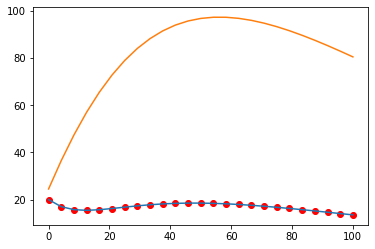

In [464]:
plt.scatter(x_true, y_true.numpy(), color='red')
plt.plot(x_true.numpy(), y_true.numpy())
plt.plot(x_true.numpy(), modified_f(init_p).numpy())
plt.show()

In [455]:
params = { 'x' : x_true,
           'init_p': init_p,
           'y' : y_true,
           'func' : modified_f,  # model to be fitted
           'sigma' : 4.0,    # std of datapoint
           'lambda_lm' : 10, # starting lambda
           'eps1' : 1e-3,    
           'eps2' : 1e-3,
           'eps3' : 1e-3,
           'eps4' : 1e-3,
           'lm_up' : 11,     # up coefficient
           'lm_down' : 9     # down coefficient
           }

In [448]:
lm = LevenbergMarquad(params)

In [453]:
p_hat = []
p = []
lmbd = []
for i in range(10):
    p.append(float(torch.linalg.norm(lm.step(), ord=2)))
    p_hat.append(float(torch.linalg.norm(lm.p - true_p , ord=2)))
    lmbd.append(lm.lambda_lm)

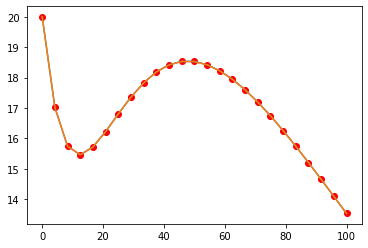

In [454]:
plt.scatter(x_true, y_true.numpy(), color='red')
plt.plot(x_true.numpy(), y_true.numpy())
#plt.plot(x_true.numpy(), modified_f(init_p).numpy())
plt.plot(x_true.numpy(), modified_f(lm.p).detach().numpy())
plt.show()

# Jacobian update

$$
J=J+\dfrac{(\hat{y}({p}+{h})-\hat{{y}}({p})-{J} {h}){h}^{\top}}{{h}^{\top}{h}}
$$